# <img src="https://img.icons8.com/bubbles/50/000000/mind-map.png" style="height:50px;display:inline"> ECE 046211 - Technion - Deep Learning
---

## HW3 - Sequential Tasks and Training Methods
---

### <img src="https://img.icons8.com/clouds/96/000000/keyboard.png" style="height:50px;display:inline"> Keyboard Shortcuts
---
* Run current cell: **Ctrl + Enter**
* Run current cell and move to the next: **Shift + Enter**
* Show lines in a code cell: **Esc + L**
* View function documentation: **Shift + Tab** inside the parenthesis or `help(name_of_module)`
* New cell below: **Esc + B**
* Delete cell: **Esc + D, D** (two D's)

### <img src="https://img.icons8.com/bubbles/50/000000/information.png" style="height:50px;display:inline"> Students Information
---
* Fill in

|Name     |Campus Email| ID  |
|---------|--------------------------------|----------|
|Lilach Biton| lilach.biton@campus.technion.ac.il| 205764517|
|Hadassa Levy| Hadassa@campus.technion.ac.il| 316155944|


### <img src="https://img.icons8.com/bubbles/50/000000/upload-to-cloud.png" style="height:50px;display:inline"> Submission Guidelines
---
* Maximal garde: 100.
* Submission only in **pairs**.
    * Please make sure you have registered your group in Moodle (there is a group creation component on the Moodle where you need to create your group and assign members).
* **No handwritten submissions.** You can choose whether to answer in a Markdown cell in this notebook or attach a PDF with your answers.
* <a style='color:red'> SAVE THE NOTEBOOKS WITH THE OUTPUT, CODE CELLS THAT WERE NOT RUN WILL NOT GET ANY POINTS! </a>
* What you have to submit:
    * If you have answered the questions in the notebook, you should submit this file only, with the name: `ece046211_hw3_id1_id2.ipynb`.
    * If you answered the questionss in a different file you should submit a `.zip` file with the name `ece046211_hw3_id1_id2.zip` with content:
        * `ece046211_hw3_id1_id2.ipynb` - the code tasks
        * `ece046211_hw3_id1_id2.pdf` - answers to questions.
    * No other file-types (`.py`, `.docx`...) will be accepted.
* Submission on the course website (Moodle).
* **Latex in Colab** - in some cases, Latex equations may no be rendered. To avoid this, make sure to not use *bullets* in your answers ("* some text here with Latex equations" -> "some text here with Latex equations").

### <img src="https://img.icons8.com/dusk/64/000000/online.png" style="height:50px;display:inline"> Working Online and Locally
---
* You can choose your working environment:
    1. `Jupyter Notebook`, **locally** with <a href="https://www.anaconda.com/distribution/">Anaconda</a> or **online** on <a href="https://colab.research.google.com/">Google Colab</a>
        * Colab also supports running code on GPU, so if you don't have one, Colab is the way to go. To enable GPU on Colab, in the menu: `Runtime`$\rightarrow$ `Change Runtime Type` $\rightarrow$`GPU`.
    2. Python IDE such as <a href="https://www.jetbrains.com/pycharm/">PyCharm</a> or <a href="https://code.visualstudio.com/">Visual Studio Code</a>.
        * Both allow editing and running Jupyter Notebooks.

* Please refer to `Setting Up the Working Environment.pdf` on the Moodle or our GitHub (https://github.com/taldatech/ee046211-deep-learning) to help you get everything installed.
* If you need any technical assistance, please go to our Piazza forum (`hw3` folder) and describe your problem (preferably with images).

### <img src="https://img.icons8.com/bubbles/50/000000/checklist.png" style="height:50px;display:inline"> Agenda
---
* [Part 1 - Theory](#-Part-1---Theory)
    * [Q1 - Masking in Transformers](#-Question-1---Masking-in-Transformers)
    * [Q2 - Preventing Variance Explosion](#-Question-2---Preventing-Variance-Explosion)
    * [Q3 - Recurrent Neural Networks](#-Question-3---Recurrent-Neural-Networks)
* [Part 2 - Code Assignments - Sequence-to-Sequence with Transformers](#-Part-2---Code-Assignments)
    * [Task 1 - Loading and Observing the Data](#-Task-1----Loading-and-Observing-the-Data)
    * [Task 2 - Preparing the Data - Separating to Inputs and Targets](#-Task-2----Preparing-the--Data---Separating-to-Inputs-and-Targets)
    * [Task 3 - Define Hyperparameters and Initialize the Model](#-Task-3----Define-Hyperparameters-and-Initialize-the-Model)
    * [Task 4 - Train and Evaluate the Language Model](#-Task-4----Train-and-Evaluate-the-Language-Model)
    * [Task 5 - Generate Sentences](#-Task-5----Generate-Sentences)
* [Credits](#-Credits)

### <img src="https://img.icons8.com/cute-clipart/64/000000/ball-point-pen.png" style="height:50px;display:inline"> Part 1 - Theory
---
* You can choose whether to answser these straight in the notebook (Markdown + Latex) or use another editor (Word, LyX, Latex, Overleaf...) and submit an additional PDF file, **but no handwritten submissions**.
* You can attach additional figures (drawings, graphs,...) in a separate PDF file, just make sure to refer to them in your answers.

* $\large\LaTeX$ <a href="https://kapeli.com/cheat_sheets/LaTeX_Math_Symbols.docset/Contents/Resources/Documents/index">Cheat-Sheet</a> (to write equations)
    * <a href="http://tug.ctan.org/info/latex-refsheet/LaTeX_RefSheet.pdf">Another Cheat-Sheet</a>

## <img src="https://img.icons8.com/clouds/100/000000/question-mark.png" style="height:50px;display:inline"> Question 1 - Masking in Transformers
---
We examine the classic encoder-decoder transformer model for next-token prediction, and focus on its masking mechanism.

1. Draw a picture of the encoder-decoder transformer model, and qualitatively explain all its parts.
2. Why do we need "Masked self-attention" in the decoder, instead of the regular self attention? Give an example with a specific task.
3. To implement Multi-Head Masked Self-Attention (MHMSA) in the decoder we use
   $$\forall i\in\{1,\ldots,H\}:\ Q_i=XW_i^Q,K_i=XW_i^K, V_i=XW_i^V$$
   $$\mathrm{MHMSA}(X)=\sum_{i=1}^H \mathrm{Softmax}\left (\frac{Q_i K_i^T}{\sqrt{d}}+M\right )V_i W_i^O$$
   Explain how should we choose $M ∈ R^{T× T}$ to implement masking based on the expression for MHMSA above, and why this works.
   
4. Why do we not require masking in the Multi-Head Self-Attention (MHSA) right after the MHMSA? Base your answer on the mathematical expression for the MHSA.
5. Explain the difference in operation of the MHMSA in training and inference. Which method is faster (assuming modern GPU hardware)?
6. A researcher though it might be useful if (similarly to vision models) we add a "max-pooling" layer with pooling size 2 on the token dimension at the end of the first decoder blocks (after the fully connected layers), to reduce its size from $T$ to $T/2$, and then extend it back to the original $T$ (e.g., by replicating the tokens) before the last decoder block. Explain why is this problematic (hint: it is related to the reason we need masking), and how to fix the issue above, allowing this max-pooling layer to be added.

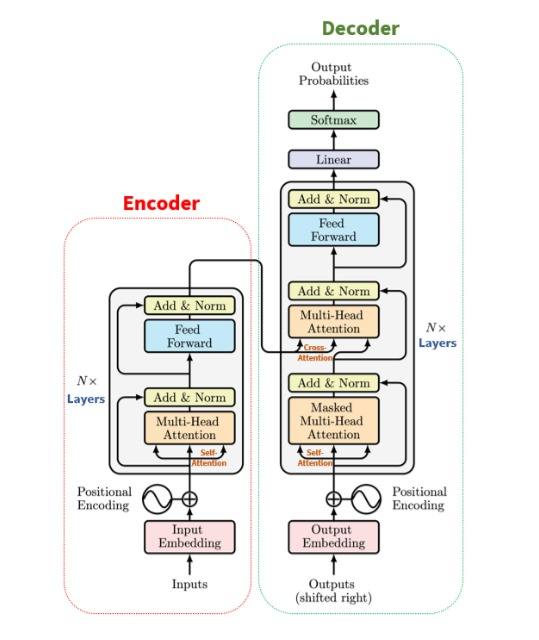

# 1.1. explanation



**Encoder-Decoder Transformer Architecture**

The Transformer consists of two main parts:

- **Encoder Block**
    - **Input Embedding:** Maps each token to a vector in in R^d.
    - **Positional Encoding:** Adds information about the position of each token, because the model has no recurrence.
    - **Multi-Head Self Attention (MHSA):** Allows each token to attend to all other tokens in the input sequence.
    - **Add & Norm:** Applies layer normalization and residual connections for stable training.
    - **Feed Forward Network (FFN):** A fully connected network applied separately to each position.
    - **Add & Norm:** Another residual connection and normalization.

- **Decoder Block**
    - **Input Embedding:** Maps previously generated tokens to vectors in $\mathbb{R}^d$.
    - **Positional Encoding:** Adds position information like in the encoder.
    - **Masked Multi-Head Self Attention (MHMSA):** Allows each token to attend only to previous tokens (to prevent seeing the future during training).
    - **Add & Norm:** Residual connection and layer normalization.
    - **Multi-Head Attention over Encoder Output:** The decoder attends to the encoder outputs, integrating the context from the input sequence.
    - **Add & Norm:** Residual connection and normalization.
    - **Feed Forward Network (FFN):** Fully connected network applied to each token.
    - **Add & Norm:** Another residual connection and normalization.

- **Final Linear + Softmax**
    - Projects decoder outputs into logits for the vocabulary.
    - Softmax converts logits into probabilities over the vocabulary for prediction.


# 1.2.
In language modeling, we generate the next token $x_{t+1}$ given all previous tokens $x_1, \ldots, x_t$. If we allow the decoder to attend to future tokens during training, it can cheat and see information it should not know yet.

For example, predicting “I like pizza”:

When generating “pizza,” the model should only see “I like.”

Without masking, it might look ahead and see “pizza,” defeating the purpose of learning next-token prediction.

Therefore, we apply a mask so each token in the decoder attends only to itself and previous tokens.

#1.3.
We choose to define the matrix \( M \) as:

$$
M_{i,j} =
\begin{cases}
0 & \text{if } j \le i \\
-\infty & \text{if } j > i
\end{cases}
$$

so after applying the softmax this works because:

- Positions \( j > i \) receive probability near zero.
- Tokens can only attend to themselves and earlier tokens.


#  1.4.
The MHSA following the masked self-attention attends to the **encoder outputs**, not the decoder’s future tokens. The encoder outputs are already fully computed and don’t change over time, so there’s no need to mask them.


# 1.5.

- **In Training**: We compute MHMSA over the entire sequence in parallel. Masking ensures correctness while allowing GPU efficiency.
- **In Inference**: We generate tokens **one by one**. For token $t$, we recompute attention only up to $t$.

Thus, **training is faster** due to full parallelism. Inference is sequential and therefore slower.


# 1.6.

Pooling merges information from multiple tokens. After pooling:

- A token at position $t$ might contain information from future tokens $t+1$ due to pooling overlap.
- This **breaks causality** required for next-token prediction.

**So for Fixing:** Replace max-pooling with **masked pooling** or causal convolutions ensuring each pooled region contains only tokens $\le t$.


## <img src="https://img.icons8.com/clouds/100/000000/question-mark.png" style="height:50px;display:inline"> Question 2 - Preventing Variance Explosion
---
This question relates to lectures 8-9 (from slide 7):

Find an initializtion scheme such that $$ \forall l, i,: \text{(1) } \mathbb{E}\left[F_l(u_l)|u_l\right]=0, \text{ (2) } Var(u_l[i]) = 1, $$ assuming skip connections: $u_{l+1} = u_l + F_l(u_l)$ with a single skip $F_l(u_l)=W_l\phi(u_l)+b_l$ and the activation is ReLU: $\phi(x) = \text{ReLU}(x) = \max(0,x)$.

## 2.

- Initialize $b_l = 0$.
- Initialize the entries of $W_l$ as:

$$
W_{l, i, j} \sim \mathcal{N}\left(0, \frac{2}{\text{fan-in}}\right)
$$

because ReLU reduces variance by about $1/2$. Thus:

$$
\text{Var} \bigl( F_l(u_l)[i] \bigr ) = 1
$$

Then, the skip connection ensures:

$$
\text{Var} \bigl( u_{l+1}[i] \bigr ) = \text{Var}(u_l[i]) + \text{Var}(F_l(u_l)[i]) = 1 + 1 = 2
$$

To keep the variance constant at 1, we scale $F_l$ by $1/\sqrt{2}$. Hence:

$$
u_{l+1} = u_l + \frac{1}{\sqrt{2}} \, F_l(u_l)
$$

which yields:

$$
\text{Var} \bigl( u_{l+1}[i] \bigr ) = 1
$$


## <img src="https://img.icons8.com/clouds/100/000000/question-mark.png" style="height:50px;display:inline"> Question 3 - Recurrent Neural Networks
---
You are given a recurrent/feedback neural network with LReLU activations $\phi(u) = \max[pu,u]$, with input $x_t$ and a representation $v_t \in \mathbb{R}^d$ that is updated as follows:
$$ \forall \tau=1,2,...t\:: v_{\tau}=\phi(u_{\tau})\:, u_{\tau} = Wv_{\tau - 1} + B x_{\tau},$$
from initialization $v_0$, and outputs $\hat{y}_t=Cv_t$. The network is trained with GD on a single long series $\{x_{\tau}, y_{\tau}\}_{\tau=1}^t$ with a cost function $\ell(y_t, \hat{y}_t)$ over the last term in the series.

1. Calculate the exact gradient $\frac{\partial \ell}{\partial W[i,j]}$ using Backpropagation through time (BPTT).
2. Recall that calculating the gradient using the method in the previous section there are two issues for $t \to \infty$: (1) the required computational resources grow indefinitely, and (2) the gradients explode or vanish. For each problem: explain it, provide an example for a method to alleviate it and describe any limitations of this method.

# 3.1.

$$
\frac{\partial \ell}{\partial \hat{y}_t}
$$


$$
\frac{\partial \ell}{\partial v_t}
=
C^T \frac{\partial \ell}{\partial \hat{y}_t}
$$

For $\tau = t, t-1, \dots, 1$:

$$
\bar{v}_{\tau-1} =
W^T \, \text{Diag}\bigl(\varphi'(u_\tau)\bigr)\, \bar{v}_{\tau}
$$

The gradient w.r.t $W$ is:

$$
\frac{\partial \ell}{\partial W}
=
\sum_{\tau=1}^{t}
\text{Diag}\bigl(\varphi'(u_\tau)\bigr)\, \bar{v}_\tau\, v_{\tau-1}^T
$$

So entry $(i,j)$:

$$
\frac{\partial \ell}{\partial W[i,j]}
=
\sum_{\tau=1}^{t}
\varphi'(u_\tau[i]) \cdot \bar{v}_\tau[i] \cdot v_{\tau-1}[j]
$$


# 3.2.

### Problem 1: Memory & Computation

- It need to store or recompute all $u_\tau$ and $v_\tau$.
- It becomes infeasible for long sequences.

**The solution:** Truncated BPTT. Backpropagate only $k$ steps backward.

**The limitation:** May miss long-term dependencies.

---

### Problem 2: Vanishing/Exploding Gradients

It is  a product of many Jacobians:

$$
\prod_{\tau = t'}^{t} \text{Diag}(\varphi'(u_\tau)) \cdot W
$$

- If spectral norm $< 1$ → gradients vanish.
- If spectral norm $> 1$ → gradients explode.

**Solutions:**

- Gradient clipping
- Orthogonal initialization
- Gated architectures (e.g. LSTM, GRU)

**Limitations:**

- The clipping get less precise gradients.
- The Gated RNNs have more parameters, and a higher complexity.


### <img src="https://img.icons8.com/officel/80/000000/code.png" style="height:50px;display:inline"> Part 2 - Code Assignments
---
* You must write your code in this notebook and save it with the output of all of the code cells.
* Additional text can be added in Markdown cells.
* You can use any other IDE you like (PyCharm, VSCode...) to write/debug your code, but for the submission you must copy it to this notebook, run the code and save the notebook with the output.

In [ ]:
!pip uninstall torchtext torch portalocker torchdata

Found existing installation: torchtext 0.15.1+cpu
Uninstalling torchtext-0.15.1+cpu:
  Would remove:
    /usr/local/lib/python3.11/dist-packages/torchtext-0.15.1+cpu.dist-info/*
    /usr/local/lib/python3.11/dist-packages/torchtext/*
Proceed (Y/n)? y
  Successfully uninstalled torchtext-0.15.1+cpu
Found existing installation: torch 2.0.0+cu117
Uninstalling torch-2.0.0+cu117:
  Would remove:
    /usr/local/bin/convert-caffe2-to-onnx
    /usr/local/bin/convert-onnx-to-caffe2
    /usr/local/bin/torchrun
    /usr/local/lib/python3.11/dist-packages/functorch/*
    /usr/local/lib/python3.11/dist-packages/nvfuser/*
    /usr/local/lib/python3.11/dist-packages/torch-2.0.0+cu117.dist-info/*
    /usr/local/lib/python3.11/dist-packages/torch/*
    /usr/local/lib/python3.11/dist-packages/torchgen/*
Proceed (Y/n)? y
  Successfully uninstalled torch-2.0.0+cu117
Found existing installation: portalocker 3.2.0
Uninstalling portalocker-3.2.0:
  Would remove:
    /usr/local/lib/python3.11/dist-packages/po

In [ ]:
!pip install torch==2.0.0+cu117 torchvision==0.15.0+cu117 torchaudio==2.0.0 torchtext==0.15.1 torchdata==0.6.0 --extra-index-url https://download.pytorch.org/whl/cu117

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu117
  Using cached https://download.pytorch.org/whl/cu117/torch-2.0.0%2Bcu117-cp311-cp311-linux_x86_64.whl (1843.9 MB)
  Using cached https://download.pytorch.org/whl/torchtext-0.15.1%2Bcpu-cp311-cp311-linux_x86_64.whl (2.0 MB)
  Using cached https://download.pytorch.org/whl/torchdata-0.6.0-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (4.6 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchtune 0.6.1 requires torchdata==0.11.0, but you have torchdata 0.6.0 which is incompatible.


In [ ]:
# this part uses the Wikitext-2 dataset. To access torchtext datasets, please install `torchdata`:
# `pip install torchdata` ir `conda install -c pytorch torchdata` in activated environment
# or `!pip install torchdata` on colab.
# !pip install torchdata
# notes:
# torch=2.0.0 <-> torchtext 0.15.1
# torch=1.13.0 <-> torchtext 0.14.0
# torch=1.12.1 <-> torchtext 0.13.1
# downgrading torchtext example: !pip install torchtext==0.13.1 --no-deps
# torchtext requires the `portalocker` package to download datasets:
!pip install portalocker==3.2.0

  Using cached portalocker-3.2.0-py3-none-any.whl.metadata (8.7 kB)
Using cached portalocker-3.2.0-py3-none-any.whl (22 kB)


In [ ]:
# imports for the practice (you can add more if you need)
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import math
from typing import Tuple
import copy

# pytorch
import torch
from torch import nn, Tensor
import torch.nn.functional as F
from torch.nn import TransformerEncoder, TransformerEncoderLayer
from torch.utils.data import dataset

# torchtext
import torchtext
from torchtext.datasets import WikiText2
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator

seed = 211
np.random.seed(seed)
torch.manual_seed(seed)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.11/dist-package

In [ ]:
print(f'pytorch: {torch.__version__}, torchtext: {torchtext.__version__}')

pytorch: 2.0.0+cu117, torchtext: 0.15.1+cpu


## <img src="https://img.icons8.com/bubbles/50/000000/workflow.png" style="height:50px;display:inline">  Sequence-to-Sequence with Transformers
---
* In this exercise, you are going to build a language model using PyTroch's Transformer module.
* We will work with the **Wikitext-2** dataset: the WikiText language modeling dataset is a collection of over 100 million tokens extracted from the set of verified Good and Featured articles on Wikipedia.
* After training, you will be able to generate senetences!

### <img src="https://img.icons8.com/color/48/000000/code.png" style="height:50px;display:inline"> Task 1  - Loading and Observing the Data
---
1. Run the following cells that define the functions `batchify` and `data_process` and initialize the tokenizer, vocabulary and the WikiText2 train dataset.
2. Create the train, valid and test data using the provided `batchify` function.
5. Print the shape of `train_data`, write in a comment the meaning of each dimension (e.g. `# [meaning of dim1, meaning of dim2]`).
6. Print the first 20 words of one training sample from `train_data`. Use the vocabulary you built to transfer between tokens to words: `itos = vocab.vocab.get_itos()` will give a "int to string" list.

In [ ]:
def batchify(data, bsz):
    """Divides the data into bsz separate sequences, removing extra elements
    that wouldn't cleanly fit.

    Args:
        data: Tensor, shape [N]
        bsz: int, batch size

    Returns:
        Tensor of shape [N // bsz, bsz]
    """
    seq_len = data.size(0) // bsz
    data = data[:seq_len * bsz]
    data = data.view(bsz, seq_len).t().contiguous()
    return data.to(device)

In [ ]:
def data_process(raw_text_iter: dataset.IterableDataset) -> Tensor:
    """Converts raw text into a flat Tensor."""
    data = [torch.tensor(vocab(tokenizer(item)), dtype=torch.long) for item in raw_text_iter]
    return torch.cat(tuple(filter(lambda t: t.numel() > 0, data)))

In [ ]:
train_iter = WikiText2(root="./data", split='train')
tokenizer = get_tokenizer('basic_english')
vocab = build_vocab_from_iterator(map(tokenizer, train_iter), specials=['<unk>'])
vocab.set_default_index(vocab['<unk>'])

In [ ]:
# train_iter was "consumed" by the process of building the vocab,
# so we have to create it again
train_iter, val_iter, test_iter = WikiText2(root="./data")
train_data = data_process(train_iter)
val_data = data_process(val_iter)
test_data = data_process(test_iter)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

device: cuda:0


In [ ]:
batch_size = 20
eval_batch_size = 10

In [ ]:
# 2. Batchify the data
# [N] -> [N // bsz, bsz]
train_data = batchify(train_data, batch_size)
val_data = batchify(val_data, eval_batch_size)
test_data = batchify(test_data, eval_batch_size)

In [ ]:
# 3. Print the shapes of the datasets
# [data length per batch (seq_len), number of batches]
print(f'train_data shape: {train_data.shape}, val_data shape: {val_data.shape}, test_data shape: {test_data.shape}')

train_data shape: torch.Size([102499, 20]), val_data shape: torch.Size([21441, 10]), test_data shape: torch.Size([24185, 10])


In [ ]:
# 4. Print the first 20 words of one training sample from `train_data`
print("first 20 tokens in the first batch:", train_data[0, :])
itos =  lambda n: vocab.vocab.get_itos()[n]
sample_words = [itos(i) for i in train_data[0,:]]
print(sample_words)

first 20 tokens in the first batch: tensor([    9,    59,   564,   223,   443, 13627,     2,   539,  2872,  2464,
            0,   313,  4513,     1,     5,    47,    66, 11652,  2435,     1],
       device='cuda:0')
['=', 'all', 'party', 'major', 'modern', 'polygamist', ',', 'present', 'arrangement', 'trying', '<unk>', 'military', 'offering', 'the', 'and', 'or', 'while', 'escaping', 'receive', 'the']


### <img src="https://img.icons8.com/color/48/000000/code.png" style="height:50px;display:inline"> Task 2  - Preparing the  Data - Separating to Inputs and Targets
---
* For a language modeling task, the model needs the following words as `Target`.
    * For example, for the senetence "I have a nice dog", the model will be given "I have a nice" as input, and "have a nice dog" as the target.
* Implement (complete) the function `get_batch(source, i, bptt)`: it generates the input and target sequence for the transformer model. It subdivides the source data into chunks of length `bptt`.
    * For example, for `bptt=2` and at `i=0`, the output of `data, target = get_batch(train_data, i=0, bptt=2)`: `data` will be of shape (2, 20), where the batch size is 20 and `target` will be of length 40 (the target for each element is two words, but we flatten `target`).
    * Example: for `bptt=2`, and the ABCDEFG... characters as input, our batches will be in the form of: `data=[a, b], target=[b, c]`. For `bptt=3`: `data=[a, b, c], target=[b, c, d]` and so on. This one example is a batch.
    * Print a sample from `data` and `target`.

In [ ]:
def get_batch(source, i, bptt):
    """
    Args:
        source: Tensor, shape [full_seq_len, batch_size]
        i: int
        bptt: int
    Returns:
        tuple (data, target), where data has shape [seq_len, batch_size] and
        target has shape [seq_len * batch_size]
    """
    seq_len = min(bptt, len(source) - 1 - i)
    data = source[i:i + seq_len]
    target = source[i+1:i + seq_len+1]
    target = target.reshape(-1)
    return data, target


data, target = get_batch(train_data, 0, 2)
print(f'data shape: {data.shape}, target shape: {target.shape}')

print("data sample token", data[:,0])
print("target sample token", target[:2])
print("data sample words", [itos(i) for i in data[:,0]])
print("target sample words", [itos(i) for i in target[:2]])

data shape: torch.Size([2, 20]), target shape: torch.Size([40])
data sample token tensor([   9, 3849], device='cuda:0')
target sample token tensor([3849,   12], device='cuda:0')
data sample words ['=', 'valkyria']
target sample words ['valkyria', '@-@']


### <img src="https://img.icons8.com/color/48/000000/code.png" style="height:50px;display:inline"> Task 3  - Define Hyperparameters and Initialize the Model
---
* Define the following hyperparameters (`[a, b]` means in the range between `a` and `b`):
    * Embedding size: choose from `[200, 250]`
    * Number of hidden units: choose from `[200, 250]`
    * Number of layers: choose from `[2, 4]`
    * Number of attention heads: choose from `[2, 4]`
    * Dropout: choose from `[0.0, 0.3]`
    * Loss criterion: `nn.CrossEntropyLoss()`
    * Optimizer: choose from `[SGD, Adam, RAdam]`
    * Learning rate: choose from `[5e-3, 5.0]`
    * Learning Scheduler: `torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.95)` or any scheduler of your choosing.
    * Transformer LayerNormalization: `post` (`norm_first=False`) or `pre` (`norm_first=True`).
* Intialize an instance of `TransformerModel` (given) and send it to `device`. Note that you need to give it the number of tokens to define the output of the decoder. You should use the number of tokens in the vocabulary. Print the number of tokens,  print **all** the chosen hyper-parameters and print the model (`print(model`).

In [ ]:
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)

class TransformerModel(nn.Module):

    def __init__(self, ntoken, ninp, nhead, nhid, nlayers, dropout=0.5, norm_first=False):
        super(TransformerModel, self).__init__()
        self.pos_encoder = PositionalEncoding(ninp, dropout)
        encoder_layers = TransformerEncoderLayer(ninp, nhead, nhid, dropout, norm_first=norm_first)
        self.transformer_encoder = TransformerEncoder(encoder_layers, nlayers)
        self.encoder = nn.Embedding(ntoken, ninp)
        self.ninp = ninp
        self.decoder = nn.Linear(ninp, ntoken)

        self.init_weights()

    def generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

    def init_weights(self):
        initrange = 0.1
        self.encoder.weight.data.uniform_(-initrange, initrange)
        self.decoder.bias.data.zero_()
        self.decoder.weight.data.uniform_(-initrange, initrange)

    def forward(self, src, src_mask):
        src = self.encoder(src) * math.sqrt(self.ninp)
        src = self.pos_encoder(src)
        output = self.transformer_encoder(src, src_mask)
        output = self.decoder(output)
        return output

In [ ]:
# Hyperparameters
Embedding = 200  #choose from `[200, 250]`
Num_hidden = 250 #choose from `[200, 250]`
Num_layers = 4
Number_attention = 2 #choose from `[2, 4]`
Dropout = 0.1
criterion = nn.CrossEntropyLoss()

# Model initialization
ntokens = len(vocab)  # size of vocabulary
print(f'Number of tokens: {ntokens}')
model = TransformerModel(ntokens, Embedding, Number_attention, Num_hidden, Num_layers, Dropout, norm_first=True)
model = model.to(device)
lr = 5e-3
optimizer = torch.optim.RAdam(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.25, patience=0)

# Print hyperparameters and model summary
print('################ Hyperparameters ################')
print('Embedding size:', Embedding)
print('Number of hidden units:', Num_hidden)
print('Number of layers:', Num_layers)
print('Number of attention heads:', Number_attention)
print('Dropout:', Dropout)
print('Loss criterion:', criterion)
print('Optimizer:', 'RAdam')
print('Learning rate:', lr)
# print('Learning Scheduler:', "torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.95)")
print('Learning Scheduler:', "torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=0)")
print('Transformer LayerNormalization:', 'post' if not model.transformer_encoder.layers[0].norm_first else 'pre')
print('################ Model ################')
print(model)

Number of tokens: 28782
################ Hyperparameters ################
Embedding size: 200
Number of hidden units: 250
Number of layers: 4
Number of attention heads: 2
Dropout: 0.1
Loss criterion: CrossEntropyLoss()
Optimizer: RAdam
Learning rate: 0.005
Learning Scheduler: torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=0)
Transformer LayerNormalization: pre
################ Model ################
TransformerModel(
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=200, out_features=200, bias=True)
        )
        (linear1): Linear(in_features=200, out_features=250, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=250, out_features=200, bias=Tr

### <img src="https://img.icons8.com/color/48/000000/code.png" style="height:50px;display:inline"> Task 4  - Train and Evaluate the Language Model
---
* Fill in the missing line in the training code and train the model.
* Use `bptt=35`.
* Use the provided function to evaluate it on the validatation set (after each epoch) and on test test (after training is done). **Print and plot** the results (loss and perplexity).
* If you see that the performance does not improve, go back to Task 3 and re-think you hyper-parameters.

In [ ]:
def evaluate(model, eval_data):
    model.eval()  # turn on evaluation mode
    total_loss = 0.
    src_mask = model.generate_square_subsequent_mask(bptt).to(device)
    with torch.no_grad():
        for i in range(0, eval_data.size(0) - 1, bptt):
            data, targets = get_batch(eval_data, i, bptt)
            seq_len = data.size(0)
            if seq_len != bptt:
                src_mask = src_mask[:seq_len, :seq_len]
            output = model(data, src_mask)
            output_flat = output.view(-1, ntokens)
            total_loss += seq_len * criterion(output_flat, targets).item()
    return total_loss / (len(eval_data) - 1)

In [ ]:
def train(model, bptt):
    model.train()  # turn on train mode
    total_loss = 0.
    log_interval = 200
    start_time = time.time()
    src_mask = model.generate_square_subsequent_mask(bptt).to(device)

    num_batches = len(train_data) // bptt
    for batch, i in enumerate(range(0, train_data.size(0) - 1, bptt)):
        data, targets = get_batch(train_data, i, bptt)
        seq_len = data.size(0)
        if seq_len != bptt:  # only on last batch
            src_mask = src_mask[:seq_len, :seq_len]
        output = model(data, src_mask)
        loss = criterion(output.view(-1, ntokens), targets)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
        optimizer.step()

        total_loss += loss.item()
        if batch % log_interval == 0 and batch > 0:
            # lr = scheduler.get_last_lr()[0]
            lr = optimizer.param_groups[0]['lr'] # Get LR from optimizer
            ms_per_batch = (time.time() - start_time) * 1000 / log_interval
            cur_loss = total_loss / log_interval
            # Cap perplexity at a reasonable value for printing
            ppl = math.exp(min(cur_loss, 100))
            print(f'| epoch {epoch:3d} | {batch:5d}/{num_batches:5d} batches | '
                  f'lr {lr:.7f} | ms/batch {ms_per_batch:5.2f} | '
                  f'loss {cur_loss:5.2f} | ppl {ppl:8.2f}')
            total_loss = 0
            start_time = time.time()

In [ ]:
best_val_loss = float("inf")
epochs = 20
best_model = None
bptt = 35
val_loss_arr = []
val_ppl_arr = []

for epoch in range(1, epochs + 1):
    epoch_start_time = time.time()
    train(model, bptt)
    val_loss = evaluate(model, val_data)
    ppl = math.exp(val_loss)
    val_loss_arr.append(val_loss)
    val_ppl_arr.append(ppl)
    print('-' * 89)
    print('| end of epoch {:3d} | time: {:5.2f}s | valid loss {:5.2f} | '
          'valid ppl {:8.2f}'.format(epoch, (time.time() - epoch_start_time),
                                     val_loss, math.exp(val_loss)))
    print('-' * 89)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = copy.deepcopy(model)


    scheduler.step(val_loss)

| epoch   1 |   200/ 2928 batches | lr 0.0050000 | ms/batch 25.83 | loss  7.15 | ppl  1273.89
| epoch   1 |   400/ 2928 batches | lr 0.0050000 | ms/batch 21.01 | loss  6.15 | ppl   470.98
| epoch   1 |   600/ 2928 batches | lr 0.0050000 | ms/batch 21.05 | loss  5.87 | ppl   353.39
| epoch   1 |   800/ 2928 batches | lr 0.0050000 | ms/batch 22.08 | loss  5.84 | ppl   345.44
| epoch   1 |  1000/ 2928 batches | lr 0.0050000 | ms/batch 21.26 | loss  5.79 | ppl   325.50
| epoch   1 |  1200/ 2928 batches | lr 0.0050000 | ms/batch 21.34 | loss  5.84 | ppl   343.18
| epoch   1 |  1400/ 2928 batches | lr 0.0050000 | ms/batch 22.26 | loss  5.88 | ppl   358.70
| epoch   1 |  1600/ 2928 batches | lr 0.0050000 | ms/batch 21.63 | loss  5.92 | ppl   372.12
| epoch   1 |  1800/ 2928 batches | lr 0.0050000 | ms/batch 21.47 | loss  5.85 | ppl   348.41
| epoch   1 |  2000/ 2928 batches | lr 0.0050000 | ms/batch 22.28 | loss  5.86 | ppl   351.23
| epoch   1 |  2200/ 2928 batches | lr 0.0050000 | ms/batch 

best validation loss 5.380831370936401
test loss 5.32518068181731
test ppl 205.44547737371684


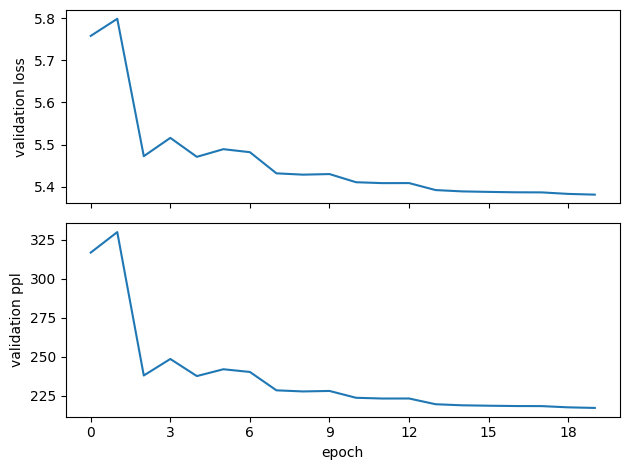

In [ ]:
from matplotlib.ticker import MaxNLocator

# best validation loss
print('best validation loss', best_val_loss)
# test loss and perplexity
test_loss = evaluate(best_model, test_data)
test_ppl = math.exp(test_loss)
print('test loss', test_loss)
print('test ppl', test_ppl)

# plot validation loss and perplexity
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
ax1.plot(val_loss_arr)
# plt.xlabel('epoch')
ax1.set_ylabel('validation loss')
# plt.show()
ax2.plot(val_ppl_arr)
ax2.set_ylabel('validation ppl')
ax2.set_xlabel('epoch')
ax2.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

### <img src="https://img.icons8.com/color/48/000000/code.png" style="height:50px;display:inline"> Task 5  - Generate Sentences
---
Use the following function to generate 3 sentences of length 20, and print them. Do they make sense? (you can compare generated sentences over epochs, to see if some logic is gained during training).

In [ ]:
def generate(model, vocab, nwords=100, temp=1.0):
    model.eval()
    ntokens = len(vocab)
    itos = vocab.vocab.get_itos()
    model_input = torch.randint(ntokens, (1, 1), dtype=torch.long).to(device)
    words = []
    with torch.no_grad():
        for i in range(nwords):
            output = model(model_input, None)
            word_weights = output[-1].squeeze().div(temp).exp().cpu()
            word_idx = torch.multinomial(word_weights, 1)[0]
            word_tensor = torch.Tensor([[word_idx]]).long().to(device)
            model_input = torch.cat([model_input, word_tensor], 0)
            word = itos[word_idx]
            words.append(word)
    return words

In [ ]:
for i in range(3):
    print(generate(best_model, vocab, nwords=20, temp=1.0))

['the', 'fact', 'which', 'he', 'has', 'played', 'in', 'the', 'lincolnshire', ',', 'and', "'", '.', 'his', 'surname', 'meyerbeer', "'", 's', '20', '@-@']
[',', 'michoacán', 'and', 'numbered', '526', 'copies', 'sold', '91', '%', ')', '.', 'although', 'this', 'allowed', 'new', 'shares', 'self', '@-@', 'released', 'below']
['empire', 'forces', 'without', 'ordination', '.', 'each', 'of', 'a', 'world', 'war', 'i', 'put', 'him', 'to', 'go', 'with', 'james', 'in', 'march', 'to']


## <img src="https://img.icons8.com/dusk/64/000000/prize.png" style="height:50px;display:inline"> Credits
---
* Icons made by <a href="https://www.flaticon.com/authors/becris" title="Becris">Becris</a> from <a href="https://www.flaticon.com/" title="Flaticon">www.flaticon.com</a>
* Icons from <a href="https://icons8.com/">Icons8.com</a> - https://icons8.com
* Datasets from <a href="https://www.kaggle.com/">Kaggle</a> - https://www.kaggle.com/